In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
import statsmodels.api as sm

In [4]:
df = pd.read_excel('../data/ENB2012_data.xlsx')

In [5]:
print(df.head(5))

     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28


In [6]:
df.columns = [
    'Compactness',
    'Surface_Area',
    'Wall_Area',
    'Roof_Area',
    'Height',
    'Orientation',
    'Glazing_Area',
    'Glazing_Distribution',
    'Heating_Load',
    'Cooling_Load'
]

print(df.columns.tolist())
print(df.shape)

['Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Height', 'Orientation', 'Glazing_Area', 'Glazing_Distribution', 'Heating_Load', 'Cooling_Load']
(768, 10)


In [13]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Compactness           768 non-null    float64
 1   Surface_Area          768 non-null    float64
 2   Wall_Area             768 non-null    float64
 3   Roof_Area             768 non-null    float64
 4   Height                768 non-null    float64
 5   Orientation           768 non-null    int64  
 6   Glazing_Area          768 non-null    float64
 7   Glazing_Distribution  768 non-null    int64  
 8   Heating_Load          768 non-null    float64
 9   Cooling_Load          768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


,Compactness,Surface_Area,Wall_Area,Roof_Area,Height,Orientation,Glazing_Area,Glazing_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [14]:
print(df['Height'].value_counts())
print(df['Orientation'].value_counts())
print(df['Glazing_Distribution'].value_counts())

Height
7.0    384
3.5    384
Name: count, dtype: int64
Orientation
2    192
3    192
4    192
5    192
Name: count, dtype: int64
Glazing_Distribution
1    144
2    144
4    144
3    144
5    144
0     48
Name: count, dtype: int64


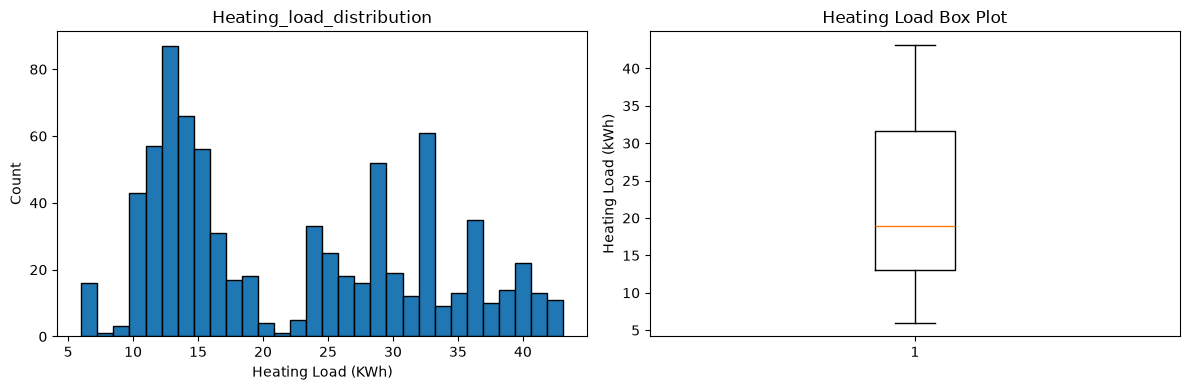

In [16]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

#distribution plot
axes[0].hist(df['Heating_Load'], bins=30, edgecolor='black')
axes[0].set_title('Heating_load_distribution')
axes[0].set_xlabel('Heating Load (KWh)')
axes[0].set_ylabel('Count')

#box plot
# box plot
axes[1].boxplot(df['Heating_Load'])
axes[1].set_title('Heating Load Box Plot')
axes[1].set_ylabel('Heating Load (kWh)')

plt.tight_layout()
plt.savefig('heating_load_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

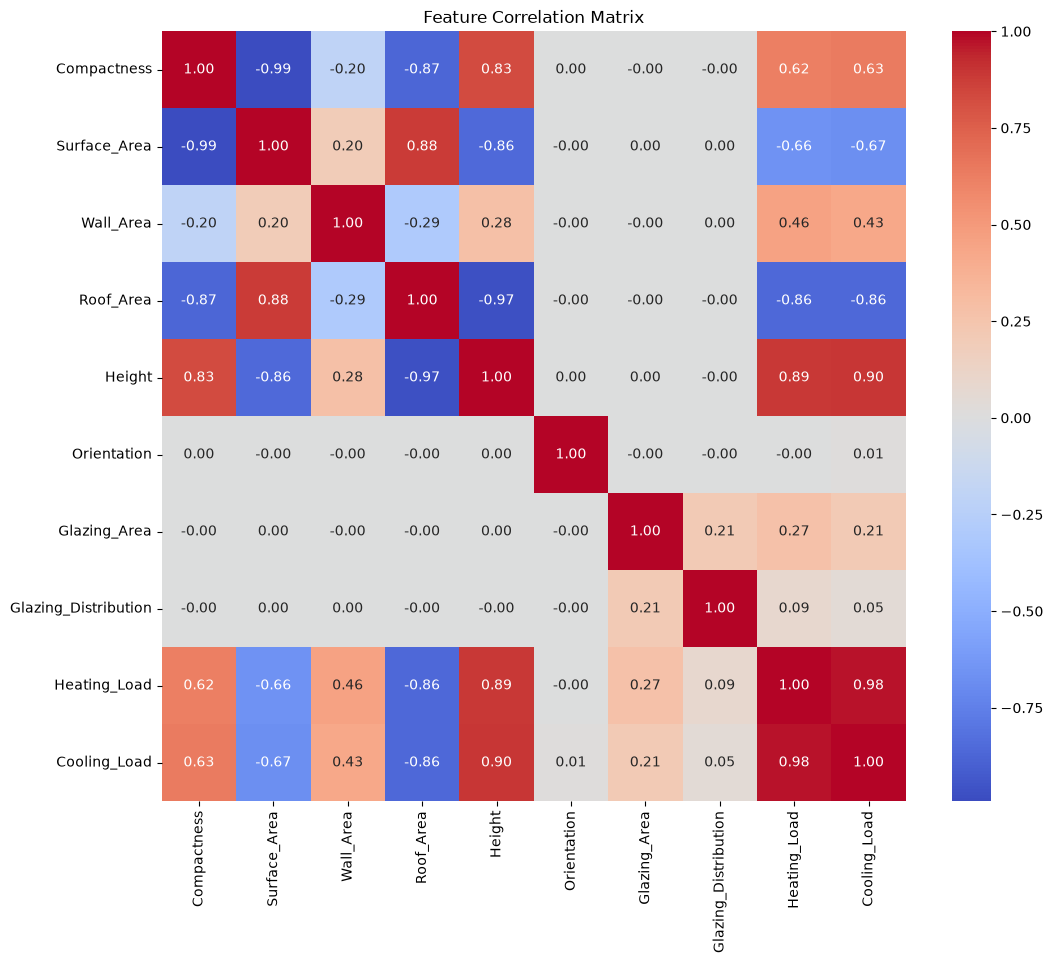

In [19]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
print("Correlations with Heating_Load:")
print(df.corr()['Heating_Load'].sort_values(ascending=False))

Correlations with Heating_Load:
Heating_Load            1.000000
Cooling_Load            0.975862
Height                  0.889430
Compactness             0.622272
Wall_Area               0.455671
Glazing_Area            0.269842
Glazing_Distribution    0.087368
Orientation            -0.002587
Surface_Area           -0.658120
Roof_Area              -0.861828
Name: Heating_Load, dtype: float64


In [21]:
print("Correlation between Height and Roof_Area:")
print(df['Height'].corr(df['Roof_Area']))
print("\nFull multicollinearity check:")
print(df[['Height', 'Roof_Area', 'Surface_Area', 'Compactness']].corr())

Correlation between Height and Roof_Area:
-0.9725122370185862

Full multicollinearity check:
                Height  Roof_Area  Surface_Area  Compactness
Height        1.000000  -0.972512     -0.858148     0.827747
Roof_Area    -0.972512   1.000000      0.880720    -0.868823
Surface_Area -0.858148   0.880720      1.000000    -0.991901
Compactness   0.827747  -0.868823     -0.991901     1.000000


In [24]:
df = df.drop(['Roof_Area', 'Surface_Area'], axis=1)
print(df.shape)
print(df.columns.tolist())

(768, 8)
['Compactness', 'Wall_Area', 'Height', 'Orientation', 'Glazing_Area', 'Glazing_Distribution', 'Heating_Load', 'Cooling_Load']


In [ ]:
X = df.drop(['Heating_Load', 'Cooling_Load'], axis=1)
y = df['Heating_Load']

print(X.shape)
print(y.shape)

(768, 6)
(768,)


In [27]:
import statsmodels.api as sm

X_with_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_with_const)
results = ols_model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           Heating_Load   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     1336.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        16:50:39   Log-Likelihood:                -1925.4
No. Observations:                 768   AIC:                             3865.
Df Residuals:                     761   BIC:                             3897.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -12.3262 

In [28]:
X = X.drop('Orientation', axis=1)
X_with_const = sm.add_constant(X)
results = sm.OLS(y, X_with_const).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           Heating_Load   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     1606.
Date:                Sun, 19 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:05:24   Log-Likelihood:                -1925.5
No. Observations:                 768   AIC:                             3863.
Df Residuals:                     762   BIC:                             3891.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -12.4078 

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

                Feature        VIF
0           Compactness  47.818771
1             Wall_Area  23.896933
2                Height  21.415797
4  Glazing_Distribution   4.480988
3          Glazing_Area   4.280321


In [30]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = X_scaled.columns
vif_data['VIF'] = [variance_inflation_factor(X_scaled.values, i)
                   for i in range(X_scaled.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

                Feature       VIF
2                Height  9.626103
0           Compactness  9.250283
1             Wall_Area  3.161934
3          Glazing_Area  1.047508
4  Glazing_Distribution  1.047508


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(614, 5)
(154, 5)


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [33]:
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(pipeline, X_train, y_train,
                            cv=5, scoring='r2')

print(f"CV R² scores:  {cv_scores}")
print(f"Mean R²:       {cv_scores.mean():.4f}")
print(f"Std R²:        {cv_scores.std():.4f}")

CV R² scores:  [0.9148828  0.9106132  0.91558354 0.91223431 0.90790643]
Mean R²:       0.9122
Std R²:        0.0028


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nTest Set Results:")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


Test Set Results:
MAE:  2.3122
MSE:  9.5266
RMSE: 3.0865
R²:   0.9086


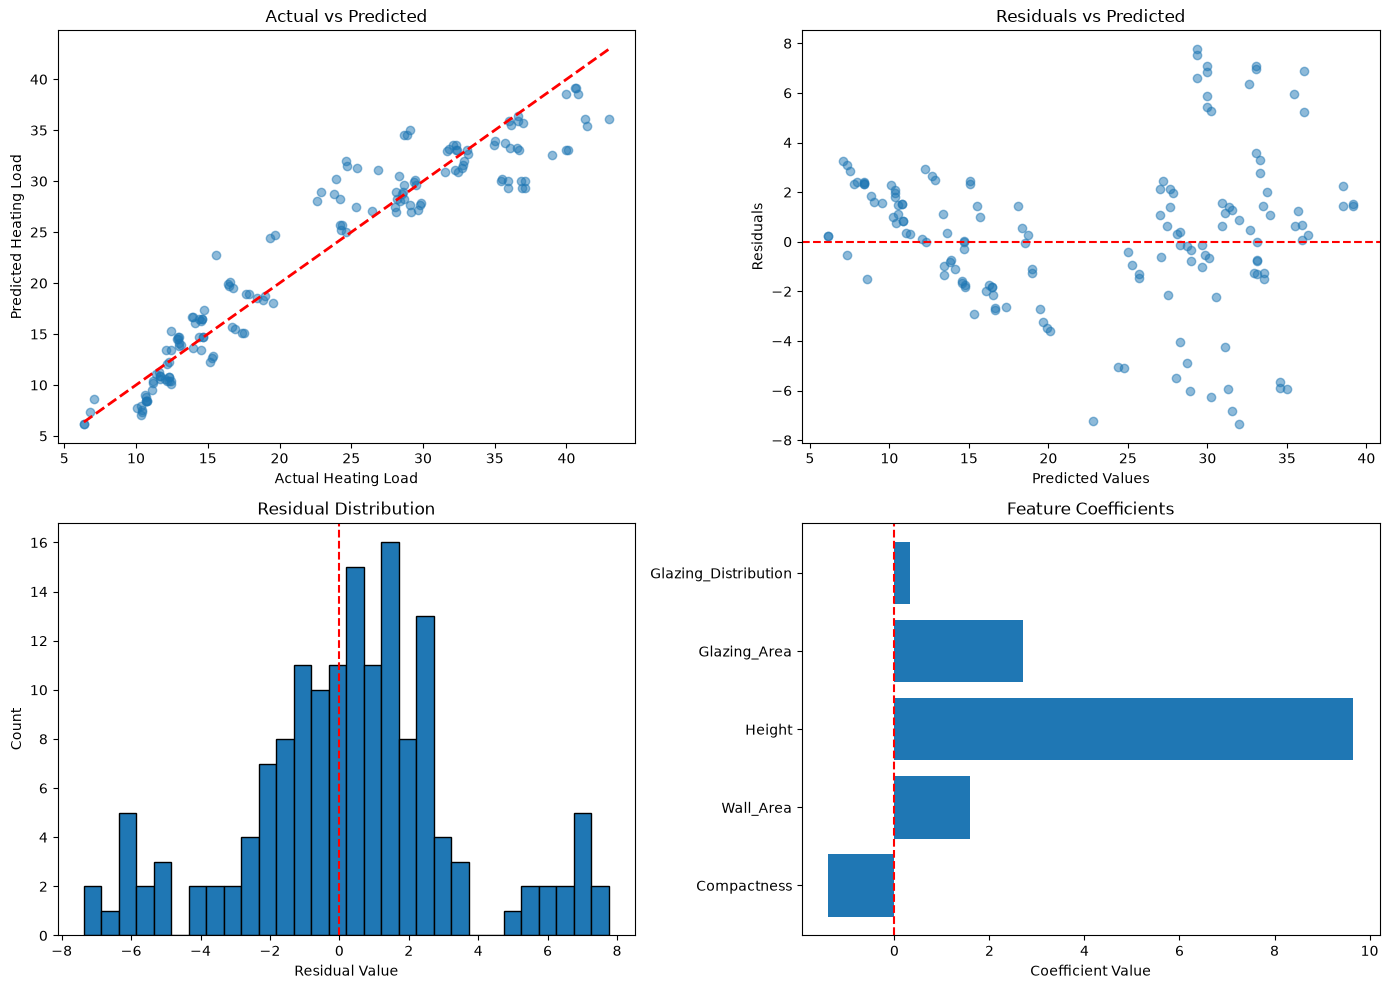

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 - Actual vs Predicted
y_pred = pipeline.predict(X_test)
residuals = y_test - y_pred

axes[0][0].scatter(y_test, y_pred, alpha=0.5)
axes[0][0].plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()],
                'r--', linewidth=2)
axes[0][0].set_xlabel('Actual Heating Load')
axes[0][0].set_ylabel('Predicted Heating Load')
axes[0][0].set_title('Actual vs Predicted')

# Plot 2 - Residuals vs Predicted
axes[0][1].scatter(y_pred, residuals, alpha=0.5)
axes[0][1].axhline(y=0, color='r', linestyle='--')
axes[0][1].set_xlabel('Predicted Values')
axes[0][1].set_ylabel('Residuals')
axes[0][1].set_title('Residuals vs Predicted')

# Plot 3 - Residual Distribution
axes[1][0].hist(residuals, bins=30, edgecolor='black')
axes[1][0].axvline(x=0, color='r', linestyle='--')
axes[1][0].set_xlabel('Residual Value')
axes[1][0].set_ylabel('Count')
axes[1][0].set_title('Residual Distribution')

# Plot 4 - Feature Coefficients
coefs = pipeline.named_steps['model'].coef_
features = X.columns
axes[1][1].barh(features, coefs)
axes[1][1].axvline(x=0, color='r', linestyle='--')
axes[1][1].set_xlabel('Coefficient Value')
axes[1][1].set_title('Feature Coefficients')

plt.tight_layout()
plt.savefig('regression_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
import mlflow
import mlflow.sklearn
import joblib
import os

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('energy-mlr-predictor')

# Run 1 - Feature selection decisions
with mlflow.start_run(run_name='feature_selection'):
    # dropped features
    mlflow.log_param('dropped_Roof_Area', 'multicollinearity VIF=21')
    mlflow.log_param('dropped_Surface_Area', 'multicollinearity VIF=24')
    mlflow.log_param('dropped_Orientation', 'p_value=0.809 not significant')

    # OLS with 6 features
    mlflow.log_metric('ols_6features_r2', 0.913)
    mlflow.log_metric('ols_6features_f_stat', 1336)

    # OLS with 5 features after dropping Orientation
    mlflow.log_metric('ols_5features_r2', 0.913)
    mlflow.log_metric('ols_5features_f_stat', 1606)
    mlflow.log_metric('ols_5features_aic', 3863)

    # VIF after scaling
    mlflow.log_metric('vif_Height', 9.63)
    mlflow.log_metric('vif_Compactness', 9.25)
    mlflow.log_metric('vif_Wall_Area', 3.16)
    mlflow.log_metric('vif_Glazing_Area', 1.05)
    mlflow.log_metric('vif_Glazing_Distribution', 1.05)

    print("Feature selection run logged!")

# Run 2 - Final model
with mlflow.start_run(run_name='final_model'):
    # parameters
    mlflow.log_param('model', 'LinearRegression')
    mlflow.log_param('scaler', 'StandardScaler')
    mlflow.log_param('features', 5)
    mlflow.log_param('test_size', 0.2)
    mlflow.log_param('random_state', 42)
    mlflow.log_param('cv_folds', 5)
    mlflow.log_param('most_impactful_feature', 'Height')

    # metrics
    mlflow.log_metric('cv_r2_mean', 0.9122)
    mlflow.log_metric('cv_r2_std', 0.0028)
    mlflow.log_metric('test_r2', 0.9086)
    mlflow.log_metric('test_mae', 2.3122)
    mlflow.log_metric('test_rmse', 3.0865)

    # coefficients
    mlflow.log_metric('coef_Height', 9.658)
    mlflow.log_metric('coef_Glazing_Area', 2.714)
    mlflow.log_metric('coef_Wall_Area', 1.591)
    mlflow.log_metric('coef_Compactness', -1.394)
    mlflow.log_metric('coef_Glazing_Distribution', 0.336)

    # diagnostic results
    mlflow.log_metric('residual_mean', 0.2891)
    mlflow.log_metric('residual_std', 3.0830)
    mlflow.log_metric('actual_vs_predicted_corr', 0.9536)
    mlflow.log_metric('shapiro_wilk_pvalue', 0.0012)

    # save model
    os.makedirs('../models', exist_ok=True)
    joblib.dump(pipeline, '../models/energy_pipeline.pkl')
    joblib.dump(list(X.columns), '../models/feature_columns.pkl')
    mlflow.log_artifact('../models/energy_pipeline.pkl')
    mlflow.log_artifact('regression_diagnostics.png')

    print("Final model run logged!")

2026/07/19 19:10:28 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/19 19:10:28 INFO mlflow.store.db.utils: Updating database tables
2026/07/19 19:10:31 INFO mlflow.tracking.fluent: Experiment with name 'energy-mlr-predictor' does not exist. Creating a new experiment.


Feature selection run logged!
Final model run logged!
